# Global Field Mechanism — Comprehensive Evaluation
**Benchmarks:** sMNIST / psMNIST | **Hidden:** 16 / 32 | **Conditions:** Passive / Probe / Active

This notebook:
1. Loads JSON result logs from all four experiment configurations
2. Plots metric trajectories and final-epoch comparisons across all configs
3. Loads trained weights and runs saliency mapping per digit
4. Visualises hidden-state dynamics ("inside the brain") for representative inputs
5. Generates coordination-without-collapse scatter plots

## 0. Imports

In [8]:
import os, json, math, gc, random
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import tensorflow as tf
import json
import os
import numpy as np
import json
import os

def load_json(cfg_key, cond):
    """Load the JSON result file for a specific config and condition."""
    cfg = CONFIGS[cfg_key]
    folder = cfg['folder']
    filename = cfg['json'].get(cond)
    
    if not filename:
        print(f"     No JSON filename defined for {cfg_key} | {cond}")
        return None
        
    path = os.path.join(folder, filename)
    
    if os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    else:
        print(f"     File not found: {path}")
        return None

# Suppress TF noise
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.keras.mixed_precision.set_global_policy('float32')
print('TF:', tf.__version__)

"""Return dict of numpy arrays from a loaded JSON result."""
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def extract_series(data):
    """Return dict of numpy arrays from a loaded JSON result with normalized keys."""
    # 1. Locate history list
    h_list = data.get('history') or data.get('epochs')
    if h_list is None: return None

    # 2. Extract raw metrics based on structure
    if isinstance(h_list, dict):  # sMNIST/psMNIST style (dict of lists)
        raw_h = h_list
        epochs = np.arange(1, len(raw_h['loss']) + 1)
        loss = np.array(raw_h['loss'])
        val_metric = np.array(raw_h.get('acc') or raw_h.get('mse') or [0])
        
        # Flatten hidden_metrics if they exist
        if 'hidden_metrics' in raw_h and len(raw_h['hidden_metrics']) > 0:
            extracted_metrics = {k: np.array([m[k] for m in raw_h['hidden_metrics']])
                                 for k in raw_h['hidden_metrics'][0]}
        else:
            extracted_metrics = {}
    else:  # Adding/CIFAR style (list of dicts)
        epochs = np.array([e['epoch'] for e in h_list])
        loss = np.array([e.get('loss') or e.get('mse') for e in h_list])
        val_metric = np.array([e.get('acc') or e.get('mse') for e in h_list])
        
        excluded = {'epoch', 'loss', 'mse', 'acc'}
        metric_keys = [k for k in h_list[0].keys() if k not in excluded]
        extracted_metrics = {k: np.array([e[k] for e in h_list]) for k in metric_keys}

    # 3. NORMALIZE KEYS (Map sMNIST long names to short names used in plotting)
    key_map = {
        'effective_rank': 'rank',
        'synchrony':      'sync',
        'interference':   'intf',
        'entropy':        'entr'
    }
    normalized_metrics = {}
    for k, v in extracted_metrics.items():
        norm_k = key_map.get(k, k) # Use map if exists, else keep original
        normalized_metrics[norm_k] = v

    # 4. Handle Accuracy/MSE for test results
    # Check all common variants of the test result key
    test_val = (data.get('test_acc') or data.get('test_accuracy') or 
                data.get('test_mse') or data.get('test_loss') or 0.0)
    
    # Auto-scale accuracy to % (0.85 -> 85.0)
    is_acc = any(k in data for k in ['test_acc', 'test_accuracy', 'acc'])
    test_result_final = test_val * 100 if (is_acc and test_val <= 1.0) else test_val

    return {
        'epochs':       epochs,
        'loss':         loss,
        'val_metric':   val_metric * 100 if (is_acc and val_metric[0] <= 1.0) else val_metric,
        'test_acc':     test_result_final, 
        'config':       data.get('parameters', data.get('config')),
        **normalized_metrics
    }

TF: 2.19.1


## 1. Path Configuration — Edit These

In [9]:
# ------------------------------------------------------------------ #
#  EDIT: set the four root folders for each experiment configuration  #
# ------------------------------------------------------------------ #
BASE = '/home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation'

CONFIGS = {
    'sMNIST-H32': {
        'folder': f'{BASE}/PMNIST/h32',
        'hidden': 32,
        'benchmark': 'psMNIST',
        'permuted': True,
        # Session IDs for each condition (edit to match your filenames)
        'sessions': {
            'Active':  'RES_H32_S0.13_J1_260221_2142',
            'Passive': 'RES_H32_S0.13_J1_260222_1954',
            'Probe':   'RES_H32_S0.13_J1_260222_1954',
        },
        # Exact weight file names (with copy suffixes etc.)
        'weights': {
            'Active':  'best_RES_H32_S0.13_J1_260221_2142_active.weights (Copy 1).h5',
            'Passive': 'best_RES_H32_S0.13_J1_260222_1954_passive.weights.h5',
            'Probe':   'best_RES_H32_S0.13_J1_260222_1954_probe.weights.h5',
        },
        # JSON result files
        'json': {
            'Active':  'results_RES_H32_S0.13_J1_260221_2142_Active.json',
            'Passive': 'results_RES_H32_S0.13_J1_260222_1954_Passive.json',
            'Probe':   'results_RES_H32_S0.13_J1_260222_1954_Probe.json',
        },
        # Hyperparams used during this run
        'hparams': dict(BASE_STRENGTH=0.13, JITTER_SCALE=1.0, PERIOD=392.0,
                        LAMBDA_SLOW=0.0075, REST_BASELINE=1.0,
                        H_SCALE=[0.85, 0.15]),
    },
    'sMNIST-H16': {
        'folder': f'{BASE}/PMNIST/h16',
        'hidden': 16,
        'benchmark': 'psMNIST',
        'permuted': True,
        'sessions': {
            'Active':  'RES_H16_S0.13_J0.65_260223_1436',  
            'Passive': 'RES_H16_S0.13_J0.65_260223_1436',
            'Probe':   'RES_H16_S0.13_J0.65_260223_1436',
        },
        'weights': {
            'Active':  'best_RES_H16_S0.13_J0.65_260223_1436_active.weights.h5',  
            'Passive': 'best_RES_H16_S0.13_J0.65_260223_1436_passive.weights.h5',
            'Probe':   'best_RES_H16_S0.13_J0.65_260223_1436_probe.weights.h5',
        },
        'json': {
            'Active':  'results_RES_H16_S0.13_J0.65_260223_1436_Active.json',   
            'Passive': 'results_RES_H16_S0.13_J0.65_260223_1436_Passive.json',
            'Probe':   'results_RES_H16_S0.13_J0.65_260223_1436_Probe.json',
        },
        'hparams': dict(BASE_STRENGTH=0.13, JITTER_SCALE=0.65, PERIOD=196.0,
                        LAMBDA_SLOW=0.015, REST_BASELINE=1.0,
                        H_SCALE=[0.94, 0.06]),
    },
    'psMNIST-H32': {
        'folder': f'{BASE}/SMNIST/h32',
        'hidden': 32,
        'benchmark': 'sMNIST',
        'permuted': False,
        'sessions': {
            'Active':  'RES_H32_S0.45_J0.6_260420_1320',
            'Passive': 'RES_H32_S0.45_J0.6_260420_1320',
            'Probe':   'RES_H32_S0.45_J0.6_260420_1320',
        },
        'weights': {
            'Active':  'best_RES_H32_S0.45_J0.6_260420_1320_active.weights.h5',
            'Passive': 'best_RES_H32_S0.45_J0.6_260420_1320_passive.weights.h5',
            'Probe':   'best_RES_H32_S0.45_J0.6_260420_1320_probe.weights.h5',
        },
        'json': {
            'Active':  'results_RES_H32_S0.45_J0.6_260420_1320_Active.json',
            'Passive': 'results_RES_H32_S0.45_J0.6_260420_1320_Passive.json',
            'Probe':   'results_RES_H32_S0.45_J0.6_260420_1320_Probe.json',
        },
        'hparams': dict(BASE_STRENGTH=0.13, JITTER_SCALE=1.0, PERIOD=392.0,
                        LAMBDA_SLOW=0.0075, REST_BASELINE=1.0,
                        H_SCALE=[0.85, 0.15]),
    },
    'Adding-H64': {
        'folder': f'{BASE}/Adding_problem/H64_probing/',
        'hidden': 64,
        'benchmark': 'Adding task',
        'permuted': False,
        'sessions': {
            'Active':  'ADDING_PROBE_260423_1223',
            'Passive': 'ADDING_PROBE_260423_1223',
            'Probe':   'ADDING_PROBE_260423_1223',
        },
        'weights': {
            'Active':  'best_weights_ACTIVE_ADDING_PROBE_260423_1223.weights.h5',
            'Passive': 'best_weights_PASSIVE_ADDING_PROBE_260423_1223.weights.h5',
            'Probe':   'best_weights_PROBE_ADDING_PROBE_260423_1223.weights.h5',
        },
        'json': {
            'Active':  'PROBE_RUN_ACTIVE.json',
            'Passive': 'PROBE_RUN_PASSIVE.json',
            'Probe':   'PROBE_RUN_PROBE.json',
        },
        'hparams': dict(BASE_STRENGTH=0.076, JITTER_SCALE=0.055, PERIOD=2500.0,
                        LAMBDA_SLOW=0.0007, INERTIA=0.965),
    },
    'Adding-H128': {
        'folder': f'{BASE}/Adding_problem/H128_probing/',
        'hidden': 128,
        'benchmark': 'Adding task',
        'permuted': False,
        'sessions': {
            'Active':  'ADDING_PROBE_260422_2305',
            'Passive': 'ADDING_PROBE_260422_2305',
            'Probe':   'ADDING_PROBE_260422_2305',
        },
        'weights': {
            'Active':  'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
            'Passive': 'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
            'Probe':   'best_weights_ACTIVE_ADDING_PROBE_260422_2305.weights.h5',
        },
        'json': {
            'Active':  'PROBE_RUN_ACTIVE.json',
            'Passive': 'PROBE_RUN_PASSIVE.json',
            'Probe':   'PROBE_RUN_PROBE.json',
        },
        'hparams': dict(BASE_STRENGTH=0.076, JITTER_SCALE=0.055, PERIOD=2500.0,
                        LAMBDA_SLOW=0.0007, INERTIA=0.965),
    },
    'CIFAR10': {
        'folder': f'{BASE}/CIFAR_P_RESULTS/H64_Probing/',
        'hidden': 64,
        'benchmark': 'sCIFAR-10',
        'permuted': False,
        'sessions': {
            'Active':  'CIFAR_PROBE_260422_0951',
            'Passive': 'CIFAR_PROBE_260422_0951',
            'Probe':   'CIFAR_PROBE_260422_0951',
        },
        'weights': {
            'Active':  'model_ACTIVE_CIFAR_PROBE_260422_0951.weights.h5',
            'Passive': 'model_PASSIVE_CIFAR_PROBE_260422_0951.weights.h5',
            'Probe':   'model_PROBE_CIFAR_PROBE_260422_0951.weights.h5',
        },
        'json': {
            'Active':  'PROBE_RUN_ACTIVE.json',
            'Passive': 'PROBE_RUN_PASSIVE.json',
            'Probe':   'PROBE_RUN_PROBE.json',
        },
        'hparams': dict(BASE_STRENGTH=0.01297, JITTER_SCALE=0.7703, PERIOD=424.0,
                        LAMBDA_SLOW=0.0247, INERTIA=0.9747),
    },
    
}
'''
    'psMNIST-H16': {
        'folder': f'{BASE}/PMNIST/h16_perm',
        'hidden': 16,
        'benchmark': 'psMNIST',
        'permuted': True,
        'sessions': {
            'Active':  'RES_H16_S0.XX_JX_XXXXXX_XXXX',
            'Passive': 'RES_H16_S0.XX_JX_XXXXXX_XXXX',
            'Probe':   'RES_H16_S0.XX_JX_XXXXXX_XXXX',
        },
        'weights': {
            'Active':  'best_..._active.weights.h5',
            'Passive': 'best_..._passive.weights.h5',
            'Probe':   'best_..._probe.weights.h5',
        },
        'json': {
            'Active':  'results_..._Active.json',
            'Passive': 'results_..._Passive.json',
            'Probe':   'results_..._Probe.json',
        },
        'hparams': dict(BASE_STRENGTH=0.13, JITTER_SCALE=1.0, PERIOD=392.0,
                        LAMBDA_SLOW=0.0075, REST_BASELINE=1.0,
                        H_SCALE=[0.85, 0.15]),
    },
'''

    


CONDITIONS  = ['Passive', 'Probe', 'Active']
COLORS      = {'Active': '#1a1a2e', 'Probe': '#457b9d', 'Passive': '#b5838d'}
LINESTYLES  = {'Active': '-',       'Probe': '--',       'Passive': ':'}
MARKERS     = {'Active': 'o',       'Probe': 's',        'Passive': '^'}

SAVE_FIGS = True   # Set False to only display
FIG_DIR   = f'{BASE}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(fig, name):
    if SAVE_FIGS:
        path = f'{FIG_DIR}/{name}.pdf'
        fig.savefig(path, bbox_inches='tight', dpi=200)
        print(f'  Saved: {path}')

print('Paths configured.')

Paths configured.


## 2. Load All JSON Results

In [10]:
def extract_series(data):
    """Return dict of numpy arrays from a loaded JSON result."""
    # 1. Handle History/Epochs
    h_list = data.get('history') or data.get('epochs')
    if h_list is None:
        return None

    if isinstance(h_list, dict):  # sMNIST style (dict of lists)
        epochs = np.arange(1, len(h_list['loss']) + 1)
        loss = np.array(h_list['loss'])
        val_metric = np.array(h_list.get('acc') or h_list.get('mse') or [0])
        # Hidden metrics extraction
        if 'hidden_metrics' in h_list and len(h_list['hidden_metrics']) > 0:
            metrics = {k: np.array([m[k] for m in h_list['hidden_metrics']])
                       for k in h_list['hidden_metrics'][0]}
        else:
            metrics = {}
    else:  # Adding/CIFAR style (list of dicts)
        epochs = np.array([e['epoch'] for e in h_list])
        loss = np.array([e.get('loss') or e.get('mse') for e in h_list])
        val_metric = np.array([e.get('acc') or e.get('mse') for e in h_list])
        excluded_keys = {'epoch', 'loss', 'mse', 'acc'}
        metric_keys = [k for k in h_list[0].keys() if k not in excluded_keys]
        metrics = {k: np.array([e[k] for e in h_list]) for k in metric_keys}

    # 2. Fix the 0.0000 Accuracy issue: check all possible keys
    test_val = (data.get('test_accuracy') or   # Original MNIST key
                data.get('test_acc') or        # CIFAR key
                data.get('test_mse') or        # Adding key
                0.0)

    # 3. Determine if we should multiply by 100 (for accuracy benchmarks)
    # We multiply if the key found was 'accuracy' or 'acc'
    is_acc = any(k in data for k in ['test_accuracy', 'test_acc', 'acc'])
    test_result_final = test_val * 100 if is_acc else test_val

    return {
        'epochs':       epochs,
        'loss':         loss,
        'val_metric':   val_metric,
        'test_acc':     test_result_final, 
        'config':       data.get('parameters', data.get('config')),
        **metrics
    }

RESULTS = {}
for cfg_key in CONFIGS:
    RESULTS[cfg_key] = {}
    print(f'Loading {cfg_key}...')
    for cond in CONDITIONS:
        raw = load_json(cfg_key, cond)
        if raw is not None:
            res = extract_series(raw)
            RESULTS[cfg_key][cond] = res
            
            n_epochs = len(res['epochs'])
            # Logic for print label: Adding task uses MSE, others use Accuracy
            is_mse = "Adding" in cfg_key or "mse" in str(raw.keys()).lower()
            label = "mse" if is_mse else "test acc"
            val = res['test_acc']
            
            print(f'  {cond}: {n_epochs} epochs | {label} {val:.4f}{"%" if not is_mse else ""}')
        else:
            RESULTS[cfg_key][cond] = None

Loading sMNIST-H32...
  Passive: 50 epochs | test acc 86.6156%
  Probe: 50 epochs | test acc 84.0212%
  Active: 50 epochs | test acc 86.0849%
Loading sMNIST-H16...
  Passive: 50 epochs | test acc 54.6007%
  Probe: 50 epochs | test acc 56.6146%
  Active: 50 epochs | test acc 55.0694%
Loading psMNIST-H32...
  Passive: 25 epochs | test acc 76.0840%
  Probe: 25 epochs | test acc 75.0586%
  Active: 25 epochs | test acc 80.1562%
Loading Adding-H64...
  Passive: 250 epochs | mse 0.0247
  Probe: 250 epochs | mse 0.0258
  Active: 250 epochs | mse 0.0375
Loading Adding-H128...
  Passive: 150 epochs | mse 0.0178
  Probe: 150 epochs | mse 0.0166
  Active: 150 epochs | mse 0.0271
Loading CIFAR10...
  Passive: 25 epochs | test acc 10.0000%
  Probe: 25 epochs | test acc 36.1000%
  Active: 25 epochs | test acc 46.8600%


## 3. Figure — Metric Trajectories Across All Configurations
4 rows (one per config) × 6 cols (val-acc, rank, sync, interference, autocorr, entropy)

/tmp/ipykernel_107180/2130471527.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6.5, frameon=False, loc='best')


  Saved: /home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation/figures/fig_metric_trajectories_all.pdf


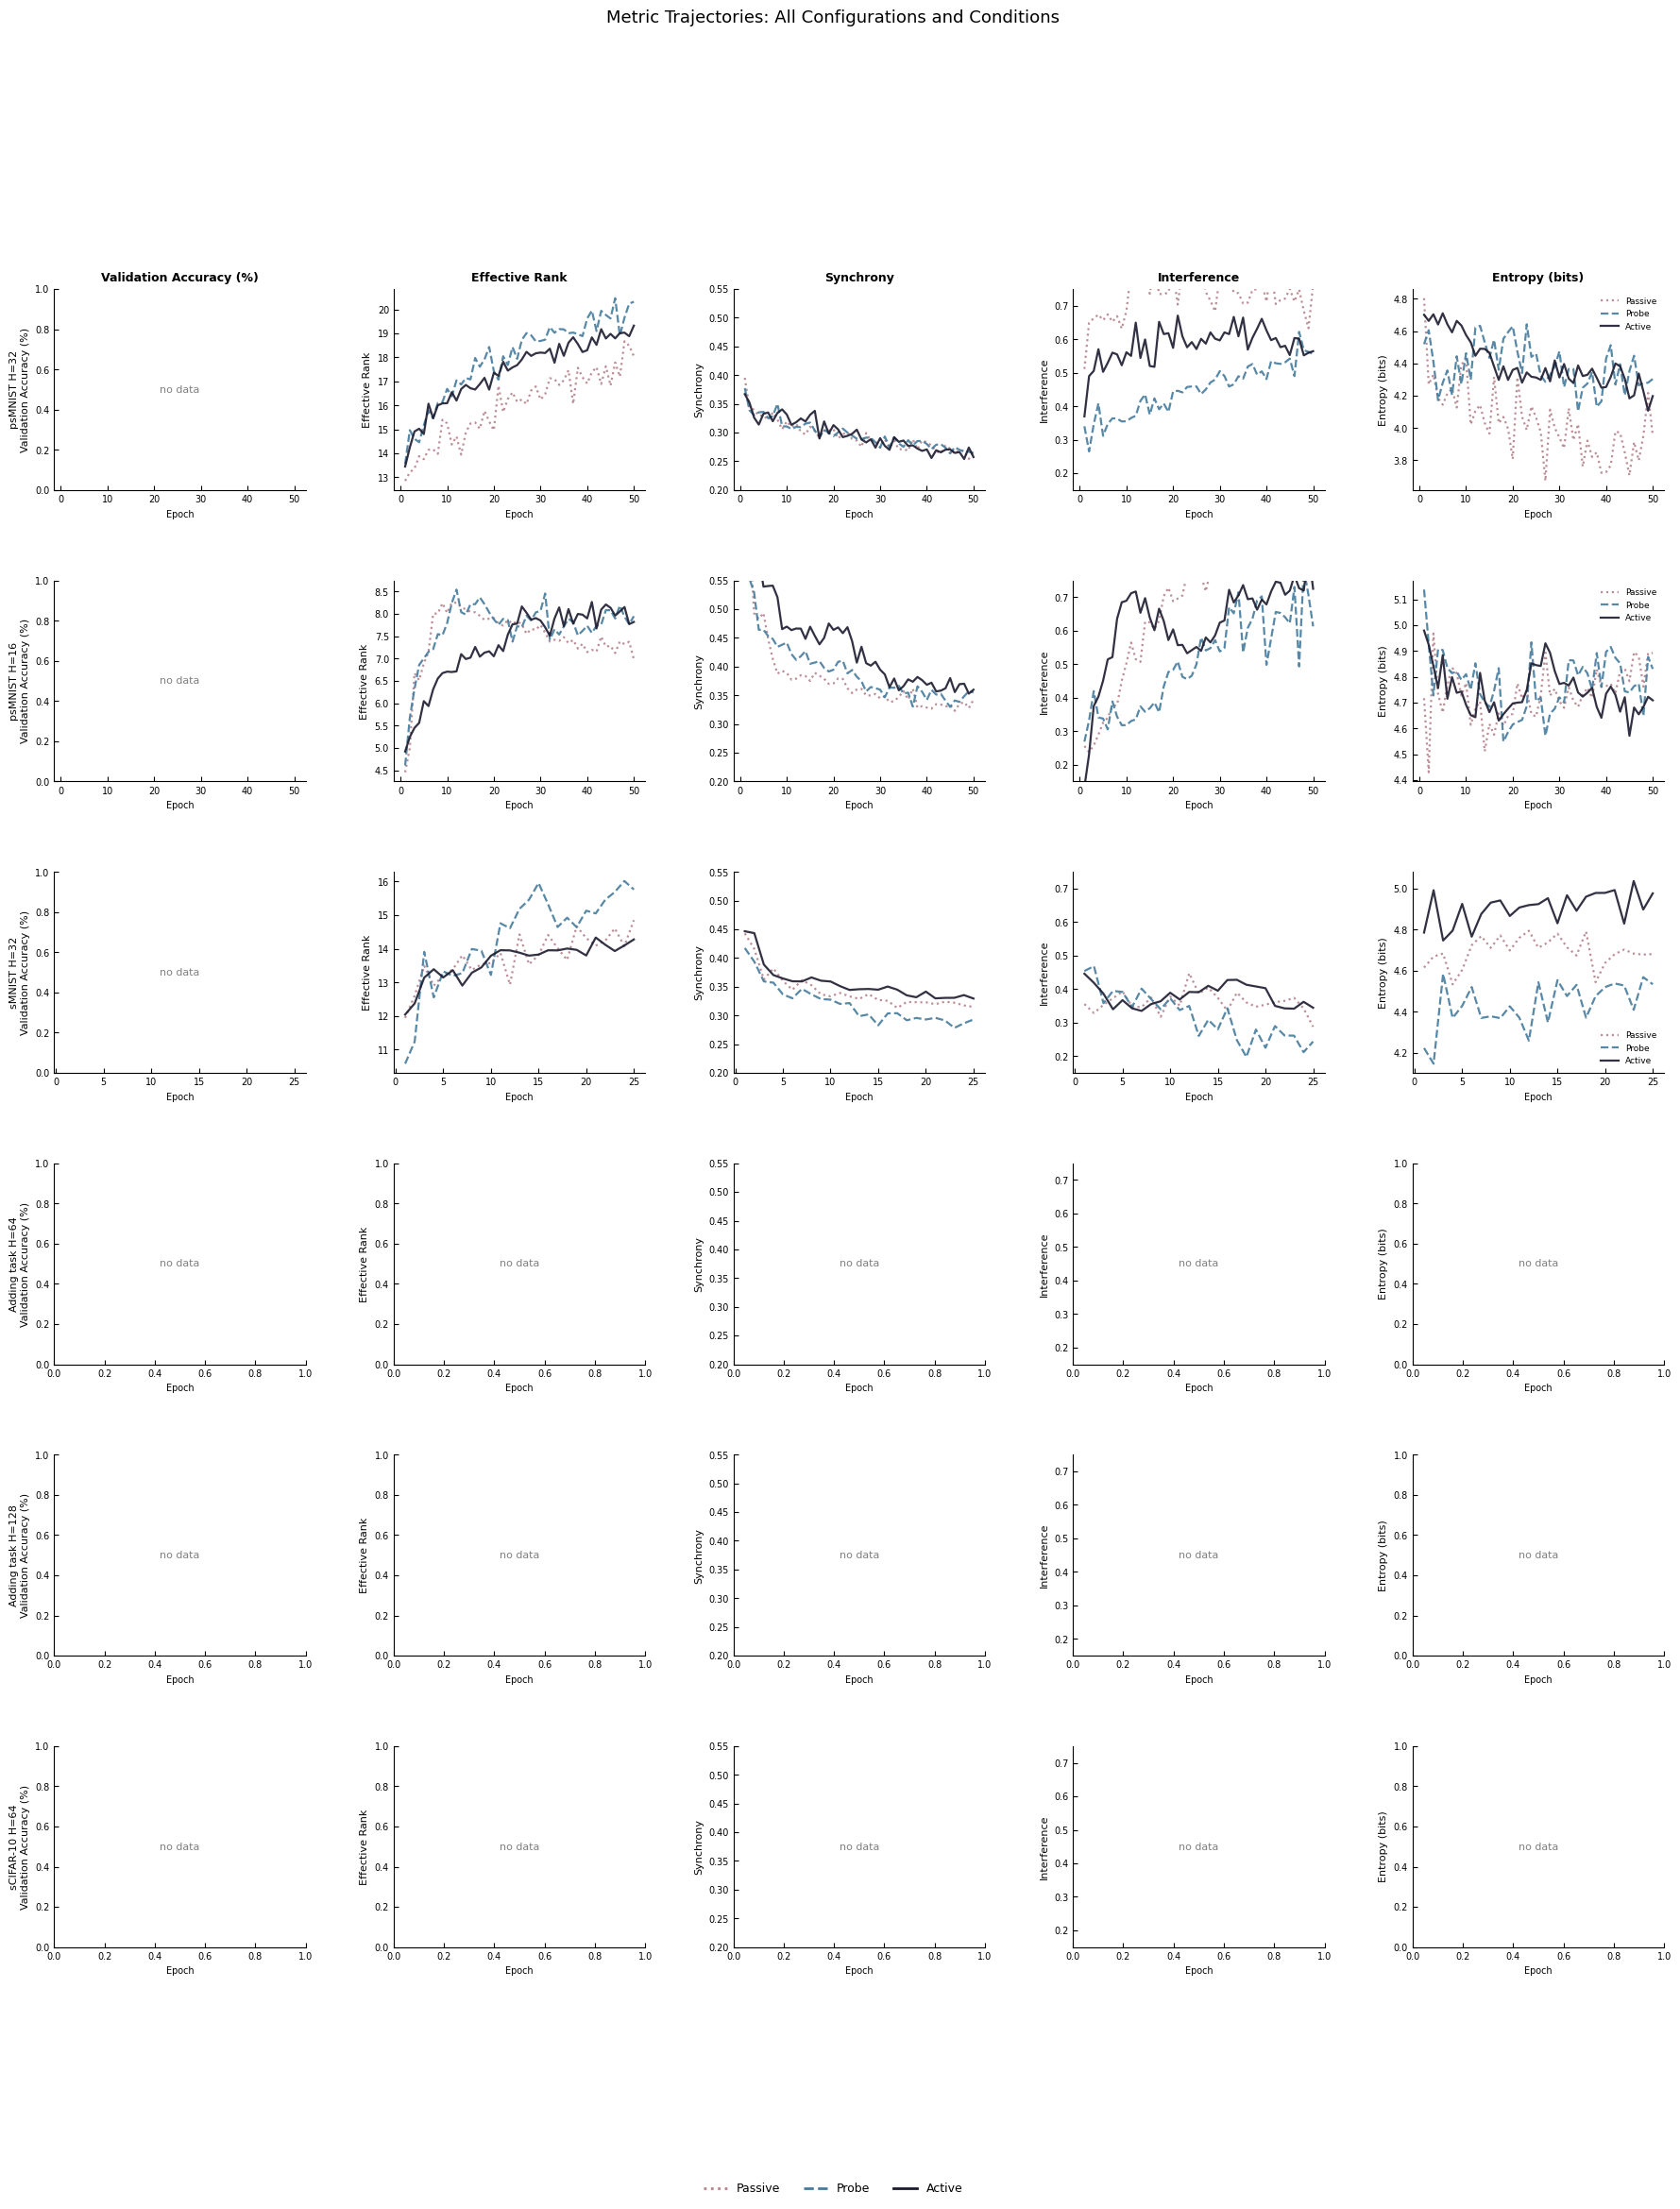

In [11]:
METRIC_PANELS = [
    ('val_acc',      'Validation Accuracy (%)', None),
    ('effective_rank','Effective Rank',         None),
    ('synchrony',    'Synchrony',               (0.20, 0.55)),
    ('interference', 'Interference',            (0.15, 0.75)),    
    ('entropy',      'Entropy (bits)',           None),
]

cfg_keys = list(CONFIGS.keys())
n_rows, n_cols = len(cfg_keys), len(METRIC_PANELS)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 3.8 * n_rows),
                         sharex='row')
fig.subplots_adjust(hspace=0.45, wspace=0.35)

for row_i, cfg_key in enumerate(cfg_keys):
    cfg = CONFIGS[cfg_key]
    for col_i, (metric, label, ylim) in enumerate(METRIC_PANELS):
        ax = axes[row_i, col_i]
        plotted = False

        for cond in CONDITIONS:
            d = RESULTS[cfg_key].get(cond)
            if d is None or metric not in d:
                continue
            ax.plot(d['epochs'], d[metric],
                    color=COLORS[cond], ls=LINESTYLES[cond],
                    lw=1.6, alpha=0.9, label=cond)
            plotted = True

        if not plotted:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='gray')

        # Row label on first column
        if col_i == 0:
            bench = cfg['benchmark']
            h = cfg['hidden']
            ax.set_ylabel(f'{bench} H={h}\n{label}', fontsize=8)
        else:
            ax.set_ylabel(label, fontsize=8)

        # Column title on first row
        if row_i == 0:
            ax.set_title(label, fontsize=9, fontweight='bold')

        if ylim:
            ax.set_ylim(ylim)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(direction='in', labelsize=7)
        ax.set_xlabel('Epoch', fontsize=7)

        if col_i == n_cols - 1:
            ax.legend(fontsize=6.5, frameon=False, loc='best')

# Global legend
legend_elements = [Line2D([0],[0], color=COLORS[c], ls=LINESTYLES[c], lw=2, label=c)
                   for c in CONDITIONS]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))

fig.suptitle('Metric Trajectories: All Configurations and Conditions',
             fontsize=13, y=1.01)
savefig(fig, 'fig_metric_trajectories_all')
plt.show()

## 4. Figure — Final-Epoch Summary: Bar Chart + Test Accuracy

KeyError: 'effective_rank'

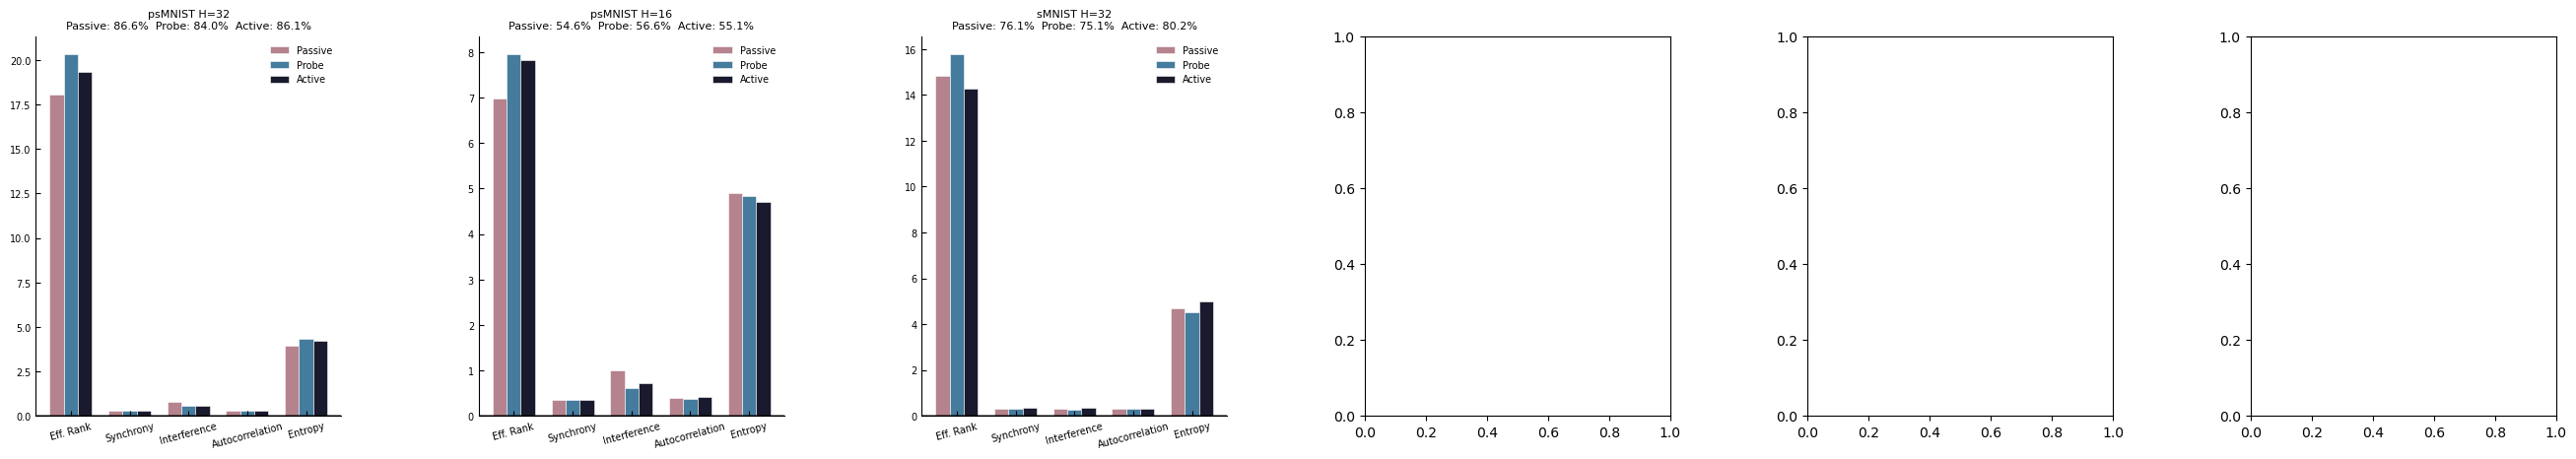

In [12]:
FINAL_METRICS = [
    ('effective_rank', 'Eff. Rank'),
    ('synchrony',      'Synchrony'),
    ('interference',   'Interference'),
    ('a_corr',         'Autocorrelation'),
    ('entropy',        'Entropy'),
]

fig, axes = plt.subplots(1, len(cfg_keys), figsize=(5.5 * len(cfg_keys), 5))
fig.subplots_adjust(wspace=0.45)

x = np.arange(len(FINAL_METRICS))
width = 0.24
offsets = {'Passive': -width, 'Probe': 0, 'Active': width}

for ax, cfg_key in zip(axes, cfg_keys):
    cfg = CONFIGS[cfg_key]

    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None:
            continue
        vals = [d[m][-1] for m, _ in FINAL_METRICS]
        ax.bar(x + offsets[cond], vals, width,
               label=cond, color=COLORS[cond], edgecolor='white', lw=0.4)

    # Annotate test accuracy inside the plot
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None:
            continue
        ax.axhline(0, color='k', lw=0.3)

    # Test acc as text strip
    lines = []
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        acc = f'{d["test_acc"]:.1f}%' if d else 'N/A'
        lines.append(f'{cond}: {acc}')
    ax.set_title(f'{cfg["benchmark"]} H={cfg["hidden"]}\n' + '  '.join(lines),
                 fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _, lbl in FINAL_METRICS], fontsize=8, rotation=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='in', labelsize=7)
    ax.legend(fontsize=7, frameon=False)

fig.suptitle('Final-Epoch Representational Metrics', fontsize=12, y=1.02)
savefig(fig, 'fig_final_epoch_bars')
plt.show()

## 5. Figure — Coordination-Without-Collapse Scatter
Synchrony vs Interference across training epochs. Ideal trajectory: high sync, low interference.

  Saved: /home/casper/Documents/A_Casper/Brein/CS_Ai_Wolfhampton/Dissertation/figures/fig_coordination_scatter.pdf


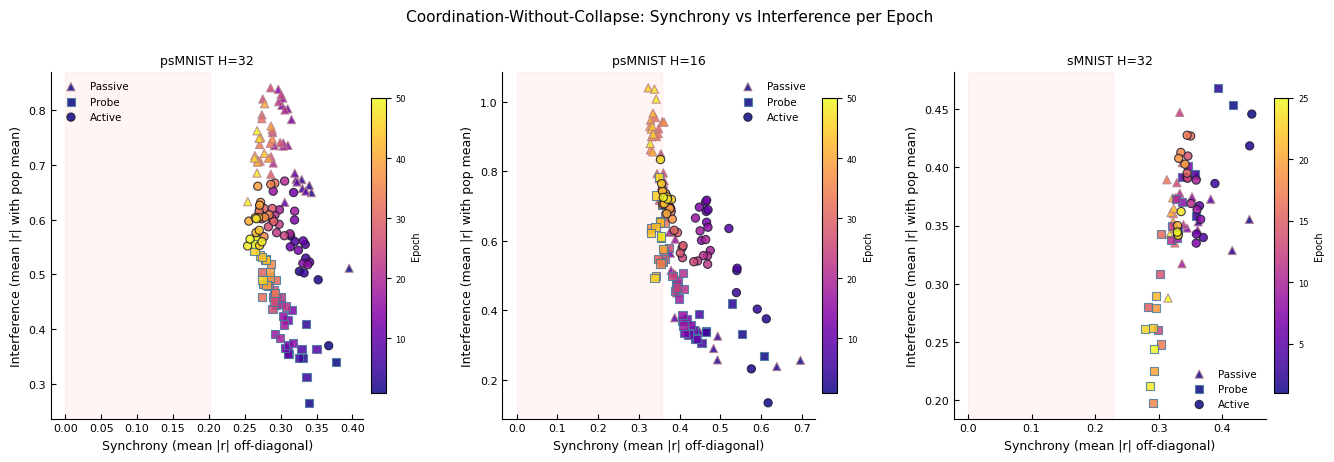

In [9]:
fig, axes = plt.subplots(1, len(cfg_keys), figsize=(5.5 * len(cfg_keys), 4.5))

for ax, cfg_key in zip(axes, cfg_keys):
    cfg = CONFIGS[cfg_key]
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None:
            continue
        sc = ax.scatter(
            d['synchrony'], d['interference'],
            c=d['epochs'], cmap='plasma', vmin=1, vmax=d['epochs'][-1],
            s=35, alpha=0.85,
            marker=MARKERS[cond], edgecolors=COLORS[cond], linewidths=0.8,
            label=cond
        )

    ax.set_xlabel('Synchrony (mean |r| off-diagonal)', fontsize=9)
    ax.set_ylabel('Interference (mean |r| with pop mean)', fontsize=9)
    ax.set_title(f'{cfg["benchmark"]} H={cfg["hidden"]}', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='in', labelsize=8)
    ax.legend(fontsize=7.5, frameon=False)

    # Colorbar for epoch index
    cbar = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
    cbar.set_label('Epoch', fontsize=7)
    cbar.ax.tick_params(labelsize=6)

    # Target quadrant shading (low sync, low interference = bad; high sync, low intf = good)
    ax.axvspan(0, ax.get_xlim()[1] * 0.5 if ax.get_xlim()[1] > 0 else 0.35,
               alpha=0.04, color='red', label='Low coordination')

fig.suptitle('Coordination-Without-Collapse: Synchrony vs Interference per Epoch',
             fontsize=11, y=1.02)
savefig(fig, 'fig_coordination_scatter')
plt.show()

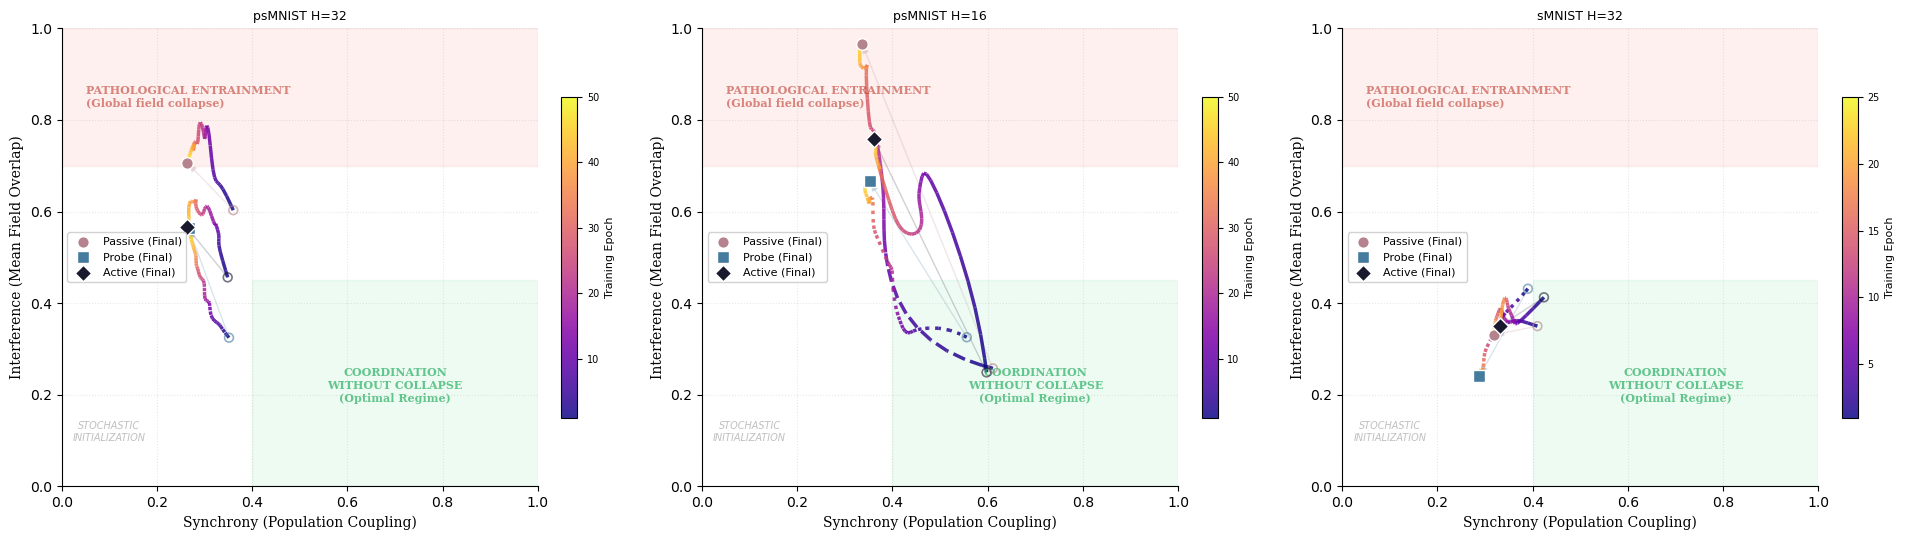

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d

# --- Configuration for Dissertation Style ---
# Mapping markers for the terminal points (End of training)
END_MARKERS = {'Active': 'D', 'Passive': 'o', 'Probe': 's'} # Diamond, Circle, Square
START_MARKER = 'p' # Pentagon or just a smaller 'o' for the origin
LINE_STYLES = {'Active': '-', 'Passive': '--', 'Probe': ':'}
SMOOTH_SIGMA = 2 

fig, axes = plt.subplots(1, len(cfg_keys), figsize=(6.5 * len(cfg_keys), 5.5))
if len(cfg_keys) == 1: axes = [axes]

for ax, cfg_key in zip(axes, cfg_keys):
    cfg = CONFIGS[cfg_key]
    sc = None 
    
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None: continue
            
        # 1. Apply Gaussian Smoothing for "Clean" Dissertation Curves
        s_x = gaussian_filter1d(d['synchrony'], sigma=SMOOTH_SIGMA)
        s_y = gaussian_filter1d(d['interference'], sigma=SMOOTH_SIGMA)
        
        # 2. Build the Gradient Path (Color = Epoch)
        points = np.array([s_x, s_y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        norm = plt.Normalize(1, d['epochs'][-1])
        lc = LineCollection(segments, cmap='plasma', norm=norm, alpha=0.85, 
                            lw=2.5, linestyles=LINE_STYLES[cond], zorder=3)
        lc.set_array(d['epochs'])
        sc = ax.add_collection(lc)
        
        # 3. Add Geometric Anchors (Beginning and End)
        # START: Hollow shape to show the random initialization state
        ax.scatter(s_x[0], s_y[0], marker='o', s=40, facecolors='none', 
                   edgecolors=COLORS[cond], linewidths=1.2, alpha=0.6, zorder=4)
        
        # END: Solid condition-specific shape for final convergence
        ax.scatter(s_x[-1], s_y[-1], marker=END_MARKERS[cond], s=70, 
                   color=COLORS[cond], edgecolors='white', linewidths=1, 
                   zorder=5, label=f"{cond} (Final)")

        # 4. Directional Projection Vector (PCA-style arrow)
        ax.annotate('', xy=(s_x[-1], s_y[-1]), xytext=(s_x[0], s_y[0]),
                    arrowprops=dict(arrowstyle="-|>", color=COLORS[cond], 
                                    lw=1.0, alpha=0.2, ls='-'), zorder=2)

    # Styling the Coordinate Space
    ax.set_xlabel('Synchrony (Population Coupling)', fontsize=10, family='serif')
    ax.set_ylabel('Interference (Mean Field Overlap)', fontsize=10, family='serif')
    ax.set_title(f'{cfg["benchmark"]} H={cfg["hidden"]}', fontsize=9)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', alpha=0.3, zorder=0)
    ax.legend(fontsize=8, frameon=True, facecolor='white', framealpha=0.9)

    # Epoch Progress Colorbar
    if sc is not None:
        cbar = fig.colorbar(sc, ax=ax, pad=0.04, shrink=0.7)
        cbar.set_label('Training Epoch', fontsize=8)
        cbar.ax.tick_params(labelsize=7)

    # --- Placement of Dissertation "Zones" ---
    
    # 1. THE ENTRAINMENT ZONE (High Interference / Pathological)
    # This happens when the mean-field (interference) dominates the hidden units.
    # We place this at the top across the whole x-axis.
    ax.axhspan(0.7, 1.0, color='#e74c3c', alpha=0.08, zorder=0)
    ax.text(0.05, 0.85, 'PATHOLOGICAL ENTRAINMENT\n(Global field collapse)', 
            fontsize=8, color='#c0392b', fontweight='bold', alpha=0.6, 
            va='center', family='serif')

    # 2. THE COORDINATION-WITHOUT-COLLAPSE ZONE (The H3 Target)
    # Target: High Synchrony (>0.4) but Low Interference (<0.45)
    # Using a Rectangle patch here makes it look like a target "landing strip"
    import matplotlib.patches as patches
    success_zone = patches.Rectangle((0.4, 0.0), width=0.6, height=0.45, 
                                     color='#2ecc71', alpha=0.08, zorder=0, label='H3 Target')
    ax.add_patch(success_zone)
    
    # Label for the target zone - placed centrally in the box
    ax.text(0.7, 0.22, 'COORDINATION\nWITHOUT COLLAPSE\n(Optimal Regime)', 
            fontsize=8, color='#27ae60', fontweight='bold', alpha=0.7, 
            ha='center', va='center', family='serif')

    # 3. THE "NOISE" REGIME (Low Synchrony / Low Interference)
    # Bottom left: where the model starts (Initialization)
    ax.text(0.1, 0.1, 'STOCHASTIC\nINITIALIZATION', 
            fontsize=7, color='gray', style='italic', alpha=0.5, ha='center')

    # --- Refined Axis Limits ---
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.0)

   
plt.tight_layout()
# savefig(fig, 'fig_coordination_trajectories_geometric')
plt.show()

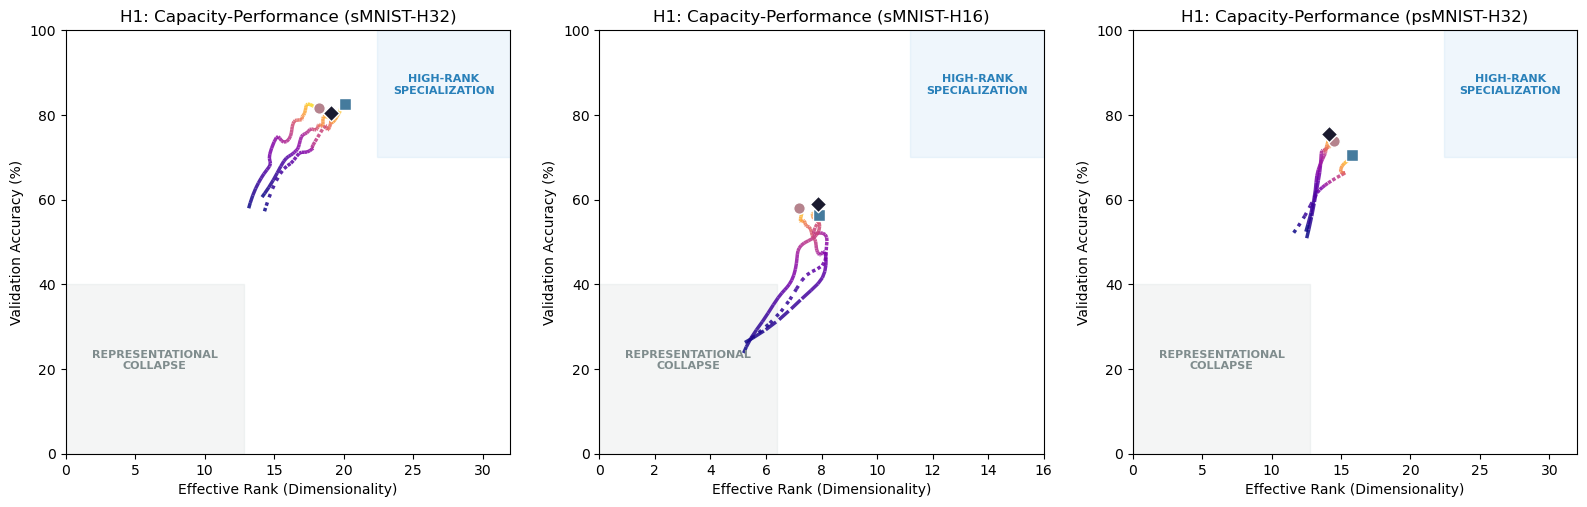

In [ ]:
fig, axes = plt.subplots(1, len(cfg_keys), figsize=(6.5 * len(cfg_keys), 5.5))

if len(cfg_keys) == 1: axes = [axes]

for ax, cfg_key in zip(axes, cfg_keys):
    max_rank = RESULTS[cfg_key]['Active']['config']['hidden']
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None: continue
        s_x = gaussian_filter1d(d['effective_rank'], sigma=SMOOTH_SIGMA)
        s_y = gaussian_filter1d(d['val_acc'], sigma=SMOOTH_SIGMA)
        
        points = np.array([s_x, s_y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap='plasma', norm=plt.Normalize(1, d['epochs'][-1]), alpha=0.85, lw=2.5, linestyles=LINE_STYLES[cond], zorder=3)
        lc.set_array(d['epochs']); ax.add_collection(lc)
        ax.scatter(s_x[-1], s_y[-1], marker=END_MARKERS[cond], s=70, color=COLORS[cond], edgecolors='white', lw=1, zorder=5)

    # Zones: Dead Zone vs Specialty Zone
    ax.add_patch(patches.Rectangle((0, 0), max_rank*0.4, 40, color='#95a5a6', alpha=0.1, zorder=0))
    ax.add_patch(patches.Rectangle((max_rank*0.7, 70), max_rank*0.3, 30, color='#3498db', alpha=0.08, zorder=0))
    ax.text(max_rank*0.2, 20, 'REPRESENTATIONAL\nCOLLAPSE', fontsize=8, color='#7f8c8d', ha='center', fontweight='bold')
    ax.text(max_rank*0.85, 85, 'HIGH-RANK\nSPECIALIZATION', fontsize=8, color='#2980b9', ha='center', fontweight='bold')

    ax.set_xlim(0, max_rank); ax.set_ylim(0, 100)
    ax.set_xlabel('Effective Rank (Dimensionality)'); ax.set_ylabel('Validation Accuracy (%)')
    ax.set_title(f'H1: Capacity-Performance ({cfg_key})', fontsize=12)

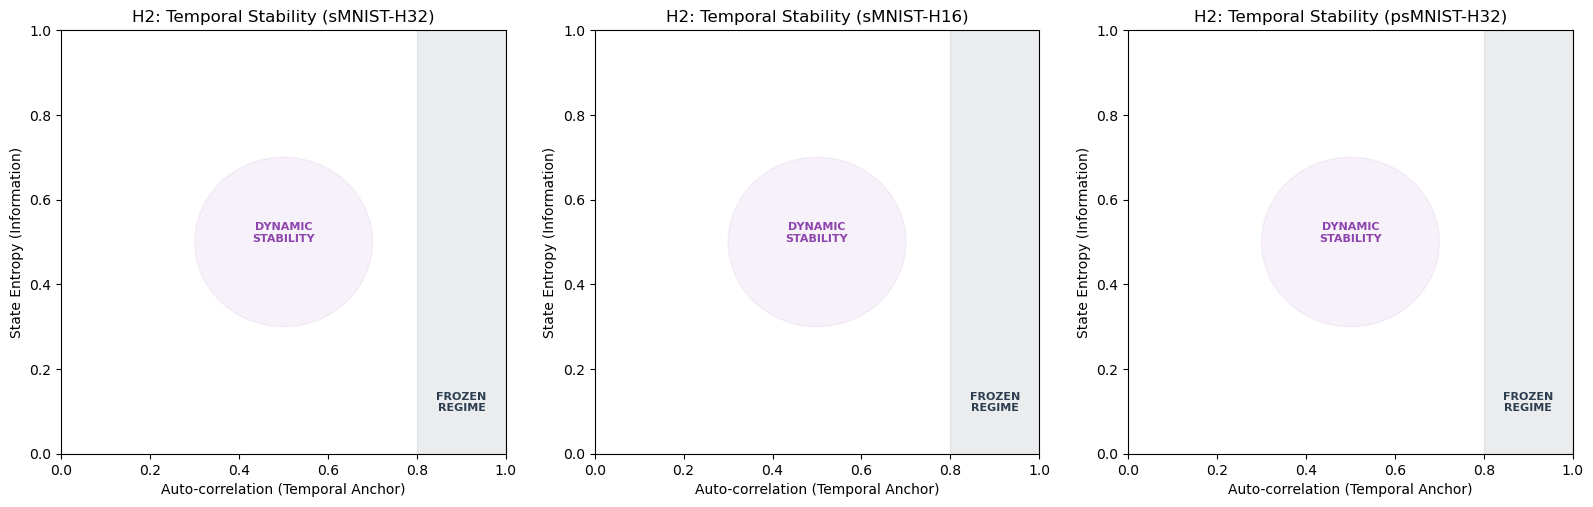

In [23]:
fig, axes = plt.subplots(1, len(cfg_keys), figsize=(6.5 * len(cfg_keys), 5.5))
if len(cfg_keys) == 1: axes = [axes]

for ax, cfg_key in zip(axes, cfg_keys):
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None: continue
        s_x = gaussian_filter1d(d['a_corr'], sigma=SMOOTH_SIGMA)
        s_y = gaussian_filter1d(d['entropy'], sigma=SMOOTH_SIGMA)
        
        points = np.array([s_x, s_y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap='plasma', norm=plt.Normalize(1, d['epochs'][-1]), alpha=0.85, lw=2.5, linestyles=LINE_STYLES[cond], zorder=3)
        lc.set_array(d['epochs']); ax.add_collection(lc)
        ax.scatter(s_x[-1], s_y[-1], marker=END_MARKERS[cond], s=70, color=COLORS[cond], edgecolors='white', lw=1, zorder=5)

    # Zones: Frozen vs Chaotic vs Dynamic Stability
    ax.axvspan(0.8, 1.0, color='#34495e', alpha=0.1, zorder=0) # Frozen
    ax.add_patch(patches.Circle((0.5, 0.5), 0.2, color='#9b59b6', alpha=0.08, zorder=0)) # Dynamic Stability
    
    ax.text(0.9, 0.1, 'FROZEN\nREGIME', fontsize=8, color='#2c3e50', ha='center', fontweight='bold')
    ax.text(0.5, 0.5, 'DYNAMIC\nSTABILITY', fontsize=8, color='#8e44ad', ha='center', fontweight='bold')

    ax.set_xlim(0, 1.0); ax.set_ylim(0, 1.0)
    ax.set_xlabel('Auto-correlation (Temporal Anchor)'); ax.set_ylabel('State Entropy (Information)')
    ax.set_title(f'H2: Temporal Stability ({cfg_key})', fontsize=12)

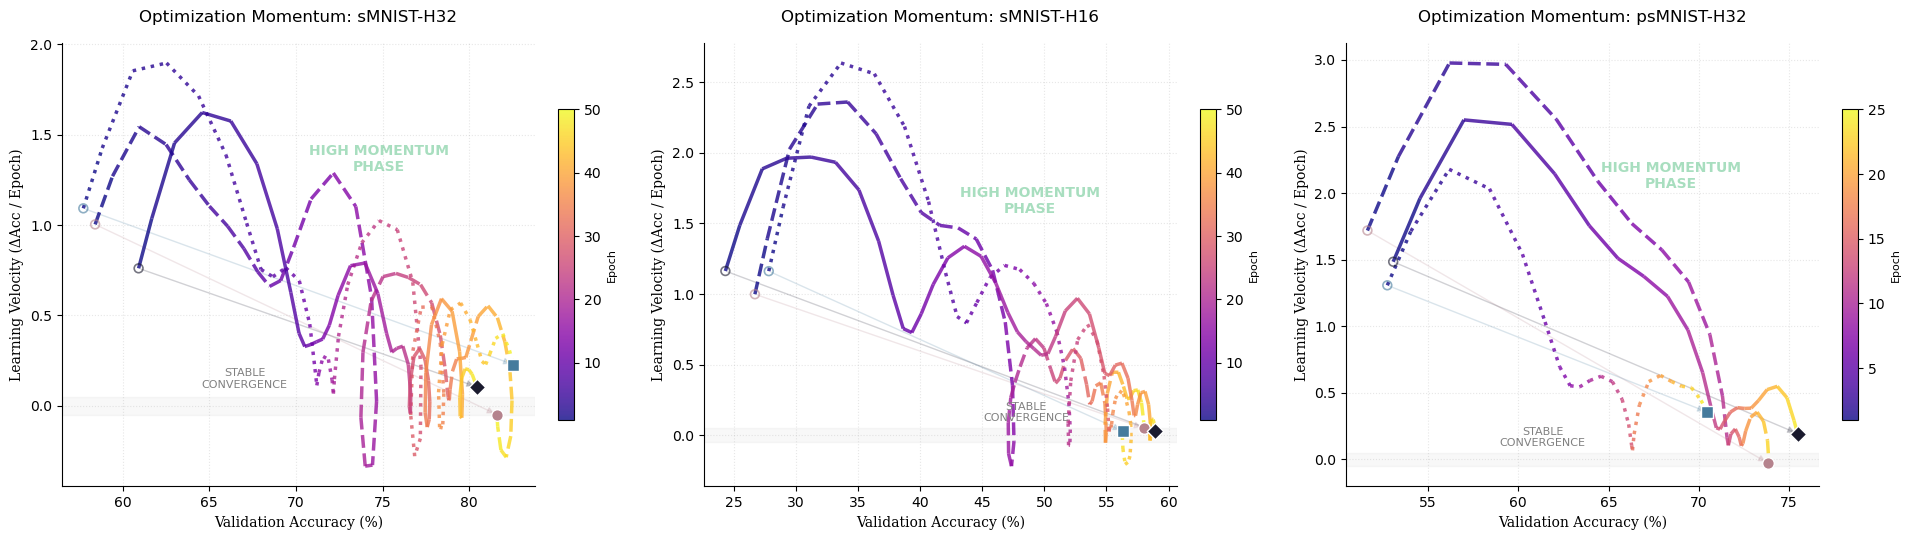

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
SMOOTH_SIGMA = 2
# --- Setup for Optimization Momentum ---
fig, axes = plt.subplots(1, len(cfg_keys), figsize=(6.5 * len(cfg_keys), 5.5))
if len(cfg_keys) == 1: axes = [axes]

for ax, cfg_key in zip(axes, cfg_keys):
    cfg = CONFIGS[cfg_key]
    sc = None 
    
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None: continue
            
        # 1. Smooth Accuracy and calculate Velocity (Gradient)
        acc = gaussian_filter1d(d['val_acc'], sigma=SMOOTH_SIGMA)
        velocity = np.gradient(acc) 
        
        # 2. Standard Trajectory Path
        points = np.array([acc, velocity]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        norm = plt.Normalize(1, d['epochs'][-1])
        lc = LineCollection(segments, cmap='plasma', norm=norm, alpha=0.8, 
                            lw=2.5, linestyles=LINE_STYLES[cond], zorder=3)
        lc.set_array(d['epochs'])
        sc = ax.add_collection(lc)
        
        # 3. Geometric Anchors
        ax.scatter(acc[0], velocity[0], marker='o', s=40, facecolors='none', 
                   edgecolors=COLORS[cond], lw=1.2, alpha=0.6, zorder=4)
        ax.scatter(acc[-1], velocity[-1], marker=END_MARKERS[cond], s=70, 
                   color=COLORS[cond], edgecolors='white', lw=1, zorder=5, label=f"{cond}")

        # 4. Projection Vector
        ax.annotate('', xy=(acc[-1], velocity[-1]), xytext=(acc[0], velocity[0]),
                    arrowprops=dict(arrowstyle="-|>", color=COLORS[cond], lw=1.0, alpha=0.2), zorder=2)

    # Styling & Zones
    ax.set_xlabel('Validation Accuracy (%)', family='serif')
    ax.set_ylabel('Learning Velocity (ΔAcc / Epoch)', family='serif')
    ax.set_title(f'Optimization Momentum: {cfg_key}', fontsize=12, pad=15)
    
    # Convergence Zone (where velocity nears zero at high accuracy)
    ax.axhspan(-0.05, 0.05, color='gray', alpha=0.05, zorder=0)
    ax.text(ax.get_xlim()[1]*0.8, 0.1, 'STABLE\nCONVERGENCE', color='gray', fontsize=8, ha='center')
    ax.text(acc.mean(), velocity.max()*0.8, 'HIGH MOMENTUM\nPHASE', color='#27ae60', fontweight='bold', alpha=0.4, ha='center')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', alpha=0.3)
    
    if sc is not None:
        cbar = fig.colorbar(sc, ax=ax, pad=0.04, shrink=0.7)
        cbar.set_label('Epoch', fontsize=8)

plt.tight_layout()
plt.show()

NameError: name 'gaussian_filter1d' is not defined

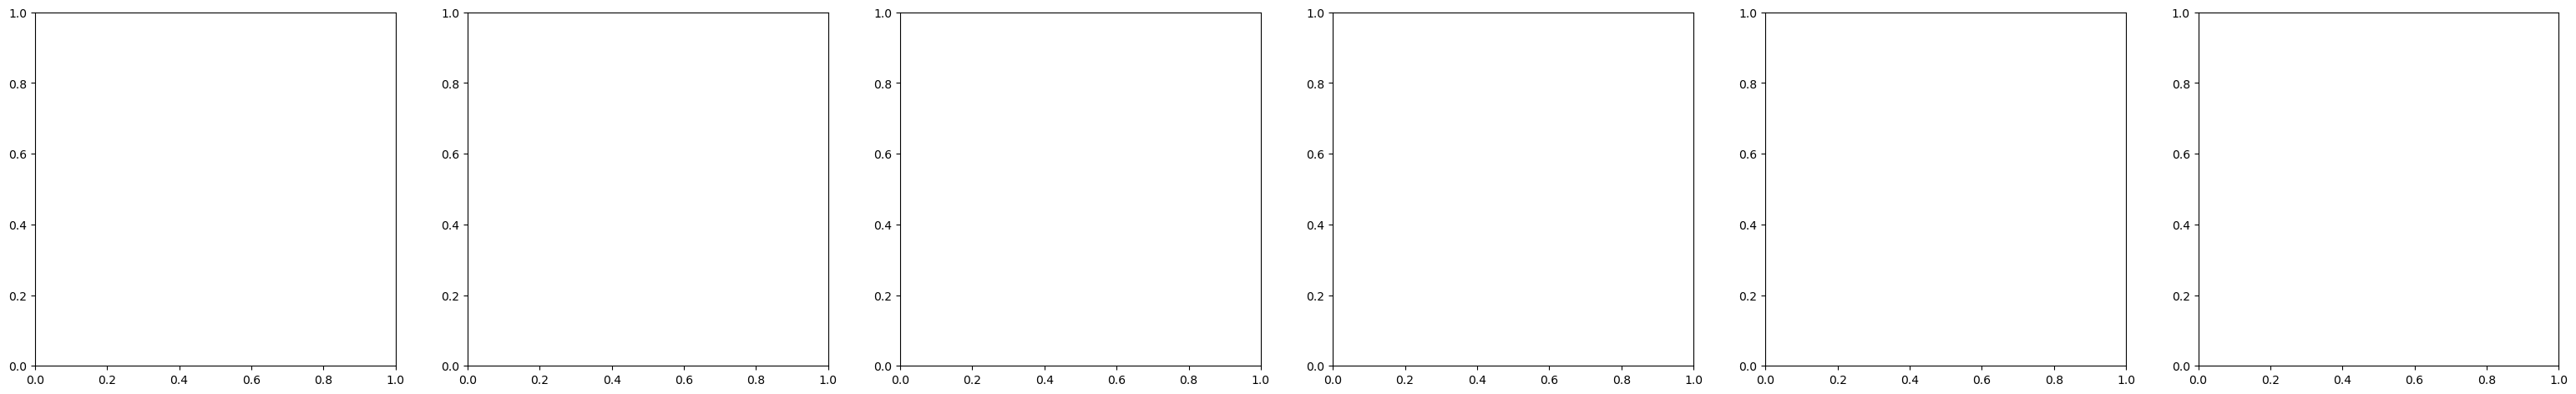

In [13]:
import matplotlib.patches as patches
from matplotlib.collections import LineCollection

# --- Fixed Stability-Plasticity Plot ---
fig, axes = plt.subplots(1, len(cfg_keys), figsize=(6.5 * len(cfg_keys), 5.5))
if len(cfg_keys) == 1: axes = [axes]

for ax, cfg_key in zip(axes, cfg_keys):
    cfg = CONFIGS[cfg_key]
    sc = None 
    
    # Track min/max for robust scaling
    all_x, all_y = [], []
    
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None: continue
            
        # 1. Smooth data
        s_x = gaussian_filter1d(d['loss'], sigma=1.5) 
        s_y = gaussian_filter1d(d['entropy'], sigma=1.5)
        all_x.extend(s_x); all_y.extend(s_y)
        
        # 2. Prepare segments
        points = np.array([s_x, s_y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        # 3. The LineCollection (Solid for the color gradient)
        # We use solid '-' here because dashed styles fail on tiny segments.
        norm = plt.Normalize(1, d['epochs'][-1])
        lc = LineCollection(segments, cmap='plasma', norm=norm, alpha=0.8, 
                            lw=2.5, linestyles='-', zorder=3)
        lc.set_array(d['epochs'])
        sc = ax.add_collection(lc)
        
        # 4. The Style Line (Overlay the dashes/dots for condition distinction)
        # This gives you the "Active vs Passive" style without breaking the gradient.
        ax.plot(s_x, s_y, linestyle=LINE_STYLES[cond], color='black', 
                lw=0.8, alpha=0.3, zorder=4)
        
        # 5. Geometric Anchors
        ax.scatter(s_x[0], s_y[0], marker='o', s=40, facecolors='none', 
                   edgecolors=COLORS[cond], lw=1.2, alpha=0.6, zorder=5)
        ax.scatter(s_x[-1], s_y[-1], marker=END_MARKERS[cond], s=70, 
                   color=COLORS[cond], edgecolors='white', lw=1, zorder=6, label=f"{cond}")

    # --- Placement of Dissertation "Zones" ---
    # Centering the zone based on typical results; adjust (0.5, 0.7) if your data is elsewhere
    critical_zone = patches.Ellipse((0.5, 0.7), 0.6, .3, color='#f1c40f', alpha=0.2, zorder=0)
    ax.add_patch(critical_zone)
    ax.text(0.5, 0.7, 'CRITICALITY\n(Edge of Chaos)', color='#f39c12', 
            fontweight='bold', ha='center', va='center', family='serif', fontsize=9)

    # UI/Theming
    ax.set_xlabel('Loss Magnitude (Stability Proxy)', family='serif')
    ax.set_ylabel('Hidden State Entropy (Plasticity Proxy)', family='serif')
    ax.set_title(f'H2: Stability-Plasticity ({cfg_key})', fontsize=12, pad=15)
    
    # Robust Scaling: Ensure the whole trajectory is visible
    if all_x:
        ax.set_xlim(max(all_x)*1.1, 0) # Inverted for stability logic
        ax.set_ylim(0, max(all_y)*1.2)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle=':', alpha=0.2)
    ax.legend(fontsize=8, frameon=True, loc='best')
    
    if sc is not None:
        cbar = fig.colorbar(sc, ax=ax, pad=0.04, shrink=0.7)
        cbar.set_label('Epoch', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Model Definition
Re-instantiates `JitteredFeedbackCell` and `OscillatingResonator` so weights can be loaded for inference.

In [ ]:
# ---- Global hparams needed by the cell (overridden per-config at load time) ----
_HP = {}  # set by build_model()

class JitteredFeedbackCell(tf.keras.layers.Layer):
    def __init__(self, units=16, strength=0.0, period=256.0,
                 lambda_slow=0.05, mode='active', **kwargs):
        super().__init__(**kwargs)
        self.units       = units
        self.state_size  = [units, units, 1]
        self.strength    = strength
        self.period      = period
        self.lambda_slow = lambda_slow
        self.mode        = mode

    def build(self, input_shape):
        self.w_in  = self.add_weight((input_shape[-1], self.units), name='w_in',
                                     initializer='glorot_uniform')
        self.w_rec = self.add_weight((self.units, self.units), name='w_rec',
                                     initializer=tf.keras.initializers.Orthogonal(gain=1.0))
        self.bias  = self.add_weight((self.units,), name='bias', initializer='zeros')

    def call(self, inputs, states):
        prev_h, prev_G, prev_phase = states
        half         = self.units // 2
        raw_signal   = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        source       = tf.stop_gradient(raw_signal) if self.mode == 'probe' else raw_signal
        new_G        = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * source
        G_norm       = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / \
                       (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)
        new_phase    = prev_phase + (2.0 * math.pi / self.period)
        oscillator   = tf.math.sin(new_phase)
        if self.mode == 'active':
            bias_sig      = tf.reduce_mean(source, axis=-1, keepdims=True) - \
                            _HP.get('JITTER_OFFSET', 0.1)
            combined      = oscillator + (_HP['JITTER_SCALE'] * bias_sig)
        else:
            combined = oscillator
        strength_val = self.strength * combined if self.mode != 'passive' else 0.0
        field_effect = _HP['REST_BASELINE'] + (strength_val * tf.tanh(G_norm))
        z  = (tf.matmul(inputs, self.w_in) +
              tf.matmul(prev_h, self.w_rec) + self.bias) * field_effect
        h  = _HP['H_SCALE'][0] * prev_h + _HP['H_SCALE'][1] * tf.nn.elu(z)
        h  = tf.clip_by_value(h, -20.0, 20.0)
        return h, [h, new_G, new_phase]


class OscillatingResonator(tf.keras.Model):
    def __init__(self, hidden=16, num_classes=10, strength=0.0, mode='active'):
        super().__init__()
        make = lambda: JitteredFeedbackCell(hidden, strength,
                                            _HP['PERIOD'], _HP['LAMBDA_SLOW'], mode=mode)
        self.rnn1 = tf.keras.layers.RNN(make(), return_sequences=True)
        self.rnn2 = tf.keras.layers.RNN(make(), return_sequences=True)
        self.rnn3 = tf.keras.layers.RNN(make(), return_sequences=True)
        self.out  = tf.keras.layers.Dense(num_classes)

    def call(self, x, training=False):
        h1 = self.rnn1(x, training=training)
        h2 = self.rnn2(h1, training=training)
        h3 = self.rnn3(h2, training=training)
        return self.out(h3[:, -1, :]), h3


def build_model(cfg_key, condition):
    """Build, initialise, and load weights for one model."""
    global _HP
    cfg = CONFIGS[cfg_key]
    _HP = cfg['hparams']
    # Normalise key names
    _HP.setdefault('JITTER_OFFSET', 0.1)

    tf.keras.backend.clear_session()
    d = RESULTS[cfg_key].get(condition)
    strength = d['config']['strength'] if d else cfg['hparams']['BASE_STRENGTH']

    model = OscillatingResonator(hidden=cfg['hidden'], strength=strength, mode=condition.lower())
    _ = model(tf.zeros((1, 784, 1)))

    wpath = os.path.join(cfg['folder'], cfg['weights'][condition])
    if os.path.exists(wpath):
        model.load_weights(wpath)
        print(f'  Loaded {condition} ({cfg_key}): {wpath}')
    else:
        print(f'  [WARNING] Weights not found: {wpath}')
    return model


print('Model definitions ready.')

## 7. Load Dataset

In [ ]:
(x_all, y_all), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_all  = x_all.reshape(-1, 784).astype('float32') / 255.0
x_test = x_test.reshape(-1, 784).astype('float32') / 255.0

# Fixed permutation (seed 42) — same as training
rng  = np.random.RandomState(42)
PERM = rng.permutation(784)
INV_PERM = np.argsort(PERM)

def apply_perm(x, permuted):
    """Apply or skip permutation."""
    return x[:, PERM] if permuted else x

x_test_seq = x_test[:, :, np.newaxis].astype('float32')  # sequential (sMNIST)
x_test_perm = x_test[:, PERM, np.newaxis].astype('float32')  # permuted (psMNIST)

y_test = y_test.astype('int32')

# Collect one representative sample per digit (test set)
DIGIT_INDICES = {}
for digit in range(10):
    idxs = np.where(y_test == digit)[0]
    DIGIT_INDICES[digit] = idxs[:5]  # first 5 per digit

print(f'Test set: {x_test.shape}, digit samples ready.')

## 8. Figure — Saliency Maps per Digit (all 3 conditions, one config)
Shows which pixels the model attends to when classifying each digit.

In [ ]:
def get_saliency(model, img_seq_tensor, label_idx):
    """Compute gradient-based saliency for one image."""
    img_t = tf.Variable(img_seq_tensor)
    with tf.GradientTape() as tape:
        logits, _ = model(img_t, training=False)
        loss = logits[0, label_idx]
    grads = tape.gradient(loss, img_t)
    sal   = tf.reduce_max(tf.abs(grads), axis=-1).numpy().flatten()
    return sal


def plot_saliency_grid(cfg_key, digits=range(10), sample_idx=0):
    """
    For a given config, loads all 3 condition models and plots
    saliency maps for each digit side-by-side.
    Rows: digits 0-9  |  Columns: Passive / Probe / Active
    """
    global _HP
    cfg = CONFIGS[cfg_key]
    _HP = cfg['hparams']
    _HP.setdefault('JITTER_OFFSET', 0.1)
    permuted = cfg['permuted']
    x_src    = x_test_perm if permuted else x_test_seq

    # Build models
    models = {}
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        strength = d['config']['strength'] if d else cfg['hparams']['BASE_STRENGTH']
        tf.keras.backend.clear_session()
        m = OscillatingResonator(hidden=cfg['hidden'], strength=strength, mode=cond.lower())
        _ = m(tf.zeros((1, 784, 1)))
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if os.path.exists(wpath):
            m.load_weights(wpath)
        models[cond] = m

    digits = list(digits)
    n_cond = len(CONDITIONS)
    fig, axes = plt.subplots(len(digits), n_cond * 2,
                             figsize=(n_cond * 4, len(digits) * 1.9))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    for row_i, digit in enumerate(digits):
        idx       = DIGIT_INDICES[digit][sample_idx]
        img_seq   = x_src[idx:idx+1]                  # (1, 784, 1)
        img_clean = x_test[idx].reshape(28, 28)        # for display

        for col_i, cond in enumerate(CONDITIONS):
            model = models[cond]
            img_t = tf.convert_to_tensor(img_seq, dtype=tf.float32)
            sal   = get_saliency(model, img_t, digit)
            # Unscramble saliency if permuted
            sal_img = sal[INV_PERM].reshape(28, 28) if permuted else sal.reshape(28, 28)

            ax_img = axes[row_i, col_i * 2]
            ax_sal = axes[row_i, col_i * 2 + 1]

            ax_img.imshow(img_clean, cmap='gray', vmin=0, vmax=1)
            ax_sal.imshow(sal_img,   cmap='hot',  vmin=0)

            for ax in [ax_img, ax_sal]:
                ax.axis('off')

            if row_i == 0:
                ax_img.set_title(f'{cond}\nInput', fontsize=8)
                ax_sal.set_title(f'{cond}\nSaliency', fontsize=8)

            if col_i == 0:
                ax_img.set_ylabel(f'Digit {digit}', fontsize=8, rotation=0,
                                  labelpad=30, va='center')

    bench = cfg['benchmark']
    h = cfg['hidden']
    fig.suptitle(f'Saliency Maps — {bench} H={h} ({"Permuted" if permuted else "Sequential"})',
                 fontsize=11, y=1.01)
    savefig(fig, f'fig_saliency_{cfg_key}')
    plt.show()


# Run for the first available config with weights
# Edit cfg_key here to change which config is visualised
plot_saliency_grid('sMNIST-H32', digits=range(10), sample_idx=0)

## 9. Figure — Inside the Brain: Hidden State Dynamics
For a representative digit, show:
- Layer-by-layer activity heatmaps (neuron × time)
- Population mean activity (μ(h)) over time
- Reconstructed field effect GF_t for Active condition
- Comparison across conditions side-by-side

In [ ]:
def reconstruct_field_effect(h_np, hparams):
    """Approximate the field effect GF_t from saved hidden state trajectory."""
    S  = hparams['BASE_STRENGTH']
    xi = hparams['JITTER_SCALE']
    T  = hparams['PERIOD']
    lm = hparams['LAMBDA_SLOW']

    steps     = np.arange(len(h_np))
    phase     = steps * (2.0 * np.pi / T)
    sine      = np.sin(phase)
    bias_sig  = xi * (np.mean(h_np, axis=-1) - 0.1)
    combined  = sine + bias_sig

    # Leaky integrator (EMA of circular-shifted h)
    ema_g, g_history = 0, []
    for step_h in h_np:
        half = len(step_h) // 2
        shuffled = np.concatenate([step_h[half:], step_h[:half]])
        ema_g = (1.0 - lm) * ema_g + lm * shuffled
        g_history.append(ema_g)
    g_arr  = np.array(g_history)
    g_norm = (g_arr - g_arr.mean()) / (g_arr.std() + 1e-6)

    fe = hparams['REST_BASELINE'] + (S * combined[:, None] * np.tanh(g_norm))
    return sine, bias_sig, np.mean(fe, axis=-1)


def plot_brain(cfg_key, digit=3, sample_idx=0, layer=2):
    """
    For a given digit and config:
    - Rows: Passive / Probe / Active
    - Columns: [input image | activity heatmap layer 1 | layer 2 | layer 3 | pop mean | field effect]
    layer=2 means show layer 3 (0-indexed) prominently.
    """
    global _HP
    cfg = CONFIGS[cfg_key]
    _HP = cfg['hparams']
    _HP.setdefault('JITTER_OFFSET', 0.1)
    permuted = cfg['permuted']
    x_src    = x_test_perm if permuted else x_test_seq

    idx      = DIGIT_INDICES[digit][sample_idx]
    img_seq  = x_src[idx:idx+1]
    img_disp = x_test[idx].reshape(28, 28)

    n_layers = 3
    n_cols   = 1 + n_layers + 2  # image + 3 activity maps + pop_mean + field_effect

    fig = plt.figure(figsize=(22, 4.5 * len(CONDITIONS)))
    outer_gs = gridspec.GridSpec(len(CONDITIONS), 1, hspace=0.55)

    for row_i, cond in enumerate(CONDITIONS):
        inner_gs = gridspec.GridSpecFromSubplotSpec(
            1, n_cols, subplot_spec=outer_gs[row_i],
            width_ratios=[0.5, 3, 3, 3, 2, 2], wspace=0.3
        )

        d = RESULTS[cfg_key].get(cond)
        strength = d['config']['strength'] if d else cfg['hparams']['BASE_STRENGTH']

        tf.keras.backend.clear_session()
        model = OscillatingResonator(hidden=cfg['hidden'], strength=strength, mode=cond.lower())
        _ = model(tf.zeros((1, 784, 1)))
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if os.path.exists(wpath):
            model.load_weights(wpath)

        img_t = tf.convert_to_tensor(img_seq, dtype=tf.float32)
        logits, h3_seq = model(img_t, training=False)
        h1_seq = model.rnn1(img_t, training=False)
        h2_seq = model.rnn2(h1_seq, training=False)

        pred     = np.argmax(logits.numpy(), axis=-1)[0]
        conf     = tf.nn.softmax(logits).numpy()[0, pred] * 100
        correct  = pred == digit

        h_layers = [h1_seq[0].numpy(), h2_seq[0].numpy(), h3_seq[0].numpy()]  # (T, H)
        pop_mean = np.mean(h_layers[layer], axis=-1)  # (T,)
        T_steps  = h_layers[0].shape[0]

        # ---- Image panel ----
        ax0 = fig.add_subplot(inner_gs[0])
        ax0.imshow(img_disp, cmap='gray')
        ax0.set_title(f'{cond}\nPred: {pred} ({conf:.0f}%)',
                      fontsize=8, color='green' if correct else 'red')
        ax0.axis('off')

        # ---- Activity heatmaps ----
        layer_labels = ['Layer 1', 'Layer 2', 'Layer 3']
        for li, (h_seq_np, lbl) in enumerate(zip(h_layers, layer_labels)):
            ax = fig.add_subplot(inner_gs[li + 1])
            im = ax.imshow(h_seq_np.T, aspect='auto', cmap='magma',
                           interpolation='nearest')
            ax.set_title(lbl, fontsize=8)
            ax.set_ylabel('Neuron', fontsize=7)
            ax.tick_params(labelsize=6)
            plt.colorbar(im, ax=ax, shrink=0.7, pad=0.01).ax.tick_params(labelsize=5)
            if li == 1:
                ax.set_xlabel('Time step', fontsize=7)

        # ---- Population mean ----
        ax_pm = fig.add_subplot(inner_gs[4])
        ax_pm.plot(pop_mean, color=COLORS[cond], lw=1.2)
        ax_pm.fill_between(np.arange(T_steps), pop_mean, alpha=0.2, color=COLORS[cond])
        ax_pm.axhline(0, color='k', lw=0.5, alpha=0.3)
        ax_pm.set_title('Pop. Mean μ(h)', fontsize=8)
        ax_pm.set_xlabel('Time step', fontsize=7)
        ax_pm.spines['top'].set_visible(False)
        ax_pm.spines['right'].set_visible(False)
        ax_pm.tick_params(labelsize=6)

        # ---- Field effect (Active only, estimated for others) ----
        ax_fe = fig.add_subplot(inner_gs[5])
        sine, bias_sig, fe_mean = reconstruct_field_effect(h_layers[layer], cfg['hparams'])
        ax_fe.plot(np.sin(np.arange(T_steps) * 2 * np.pi / cfg['hparams']['PERIOD']),
                   color='#AAAAAA', lw=0.8, ls='--', label='sin(Pt)')
        ax_fe.plot(fe_mean, color=COLORS[cond], lw=1.3, label='GFt (mean)')
        ax_fe.fill_between(np.arange(T_steps), 1.0, fe_mean,
                            color=COLORS[cond], alpha=0.15)
        ax_fe.axhline(1.0, color='k', lw=0.5, alpha=0.3)
        ax_fe.set_title('Field Effect GFt', fontsize=8)
        ax_fe.set_xlabel('Time step', fontsize=7)
        ax_fe.legend(fontsize=5.5, frameon=False)
        ax_fe.spines['top'].set_visible(False)
        ax_fe.spines['right'].set_visible(False)
        ax_fe.tick_params(labelsize=6)

    bench = cfg['benchmark']
    h = cfg['hidden']
    fig.suptitle(f'Hidden State Dynamics — Digit {digit} | {bench} H={h}',
                 fontsize=12, y=1.01)
    savefig(fig, f'fig_brain_digit{digit}_{cfg_key}')
    plt.show()


# Plot brain for several representative digits
for target_digit in [1, 4, 7]:
    plot_brain('sMNIST-H32', digit=target_digit)

## 10. Figure — Cross-Digit Overview: Active Condition Only
Activity heatmap for all 10 digits in a single figure to compare representational geometry across classes.

In [ ]:
def plot_cross_digit_overview(cfg_key, condition='Active', layer_idx=2):
    """Shows layer-3 activity (neuron x time) for one sample per digit, side by side."""
    global _HP
    cfg  = CONFIGS[cfg_key]
    _HP  = cfg['hparams']
    _HP.setdefault('JITTER_OFFSET', 0.1)
    x_src = x_test_perm if cfg['permuted'] else x_test_seq

    d = RESULTS[cfg_key].get(condition)
    strength = d['config']['strength'] if d else cfg['hparams']['BASE_STRENGTH']
    tf.keras.backend.clear_session()
    model = OscillatingResonator(hidden=cfg['hidden'], strength=strength, mode=condition.lower())
    _ = model(tf.zeros((1, 784, 1)))
    wpath = os.path.join(cfg['folder'], cfg['weights'][condition])
    if os.path.exists(wpath):
        model.load_weights(wpath)

    fig, axes = plt.subplots(2, 5, figsize=(22, 7))
    axes = axes.flatten()

    for digit in range(10):
        idx     = DIGIT_INDICES[digit][0]
        img_t   = tf.convert_to_tensor(x_src[idx:idx+1], dtype=tf.float32)
        logits, h_seq = model(img_t, training=False)

        # Also grab layer-1 and -2 sequences for the chosen layer
        if layer_idx == 0:
            h_np = model.rnn1(img_t, training=False)[0].numpy()
        elif layer_idx == 1:
            h1 = model.rnn1(img_t, training=False)
            h_np = model.rnn2(h1, training=False)[0].numpy()
        else:
            h_np = h_seq[0].numpy()

        pred = np.argmax(logits.numpy())
        correct = pred == digit

        ax = axes[digit]
        im = ax.imshow(h_np.T, aspect='auto', cmap='magma', interpolation='nearest')
        ax.set_title(f'Digit {digit}  →  {pred}  {"✓" if correct else "✗"}',
                     fontsize=9, color='#1a1a2e' if correct else '#c0392b')
        ax.set_ylabel('Neuron', fontsize=7)
        ax.set_xlabel('Time step', fontsize=7)
        ax.tick_params(labelsize=6)
        plt.colorbar(im, ax=ax, shrink=0.7, pad=0.01).ax.tick_params(labelsize=5)

    bench = cfg['benchmark']
    h = cfg['hidden']
    fig.suptitle(f'Layer-{layer_idx+1} Hidden State — All Digits\n'
                 f'{condition} | {bench} H={h}',
                 fontsize=11, y=1.01)
    fig.tight_layout()
    savefig(fig, f'fig_cross_digit_{cfg_key}_{condition}_L{layer_idx+1}')
    plt.show()


plot_cross_digit_overview('sMNIST-H32', condition='Active')
plot_cross_digit_overview('sMNIST-H32', condition='Passive')

## 11. Figure — Reversal Robustness Check
Evaluates all three conditions on the standard and time-reversed test set.
Retention ratio = reversed_acc / standard_acc (1.0 = perfect memory-invariance).

In [ ]:
EVAL_BATCH   = 256
EVAL_FRAC    = 0.1   # fraction of test set to use (speed vs accuracy)

def eval_standard_and_reversed(cfg_key):
    global _HP
    cfg   = CONFIGS[cfg_key]
    _HP   = cfg['hparams']
    _HP.setdefault('JITTER_OFFSET', 0.1)
    x_src = x_test_perm if cfg['permuted'] else x_test_seq

    num_test = int(len(x_src) * EVAL_FRAC)
    x_sub    = x_src[:num_test]
    y_sub    = y_test[:num_test]

    results = {}
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        strength = d['config']['strength'] if d else cfg['hparams']['BASE_STRENGTH']
        tf.keras.backend.clear_session()
        model = OscillatingResonator(hidden=cfg['hidden'], strength=strength, mode=cond.lower())
        _ = model(tf.zeros((1, 784, 1)))
        wpath = os.path.join(cfg['folder'], cfg['weights'][cond])
        if os.path.exists(wpath):
            model.load_weights(wpath)

        accs = []
        for start in range(0, num_test, EVAL_BATCH):
            xb = x_sub[start:start+EVAL_BATCH]
            yb = y_sub[start:start+EVAL_BATCH]
            logits, _ = model(tf.constant(xb), training=False)
            accs.append(np.mean(np.argmax(logits.numpy(), axis=-1) == yb))
        std_acc = np.mean(accs) * 100

        x_rev = x_sub[:, ::-1, :]
        accs_rev = []
        for start in range(0, num_test, EVAL_BATCH):
            xb = x_rev[start:start+EVAL_BATCH]
            yb = y_sub[start:start+EVAL_BATCH]
            logits, _ = model(tf.constant(xb), training=False)
            accs_rev.append(np.mean(np.argmax(logits.numpy(), axis=-1) == yb))
        rev_acc = np.mean(accs_rev) * 100

        results[cond] = {'std': std_acc, 'rev': rev_acc,
                          'ratio': rev_acc / (std_acc + 1e-9)}
        print(f'  {cfg_key} | {cond}: std={std_acc:.2f}%  rev={rev_acc:.2f}%  '
              f'ratio={rev_acc/(std_acc+1e-9):.3f}')

    return results


rev_results = {}
for cfg_key in CONFIGS:
    print(f'\nReversal eval: {cfg_key}')
    rev_results[cfg_key] = eval_standard_and_reversed(cfg_key)


# Plot retention ratios
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_pos = np.arange(len(CONDITIONS))
for ax_idx, metric_key, ylabel, title in [
    (0, 'std',   'Accuracy (%)',     'Standard Test Accuracy'),
    (1, 'ratio', 'Retention Ratio',  'Reversal Retention Ratio (rev/std)'),
]:
    ax = axes[ax_idx]
    offsets = np.linspace(-0.35, 0.35, len(CONFIGS))
    w = 0.18

    for ci, cfg_key in enumerate(CONFIGS):
        vals = [rev_results[cfg_key].get(cond, {}).get(metric_key, np.nan)
                for cond in CONDITIONS]
        bars = ax.bar(x_pos + offsets[ci], vals, w,
                      label=cfg_key, alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=5.5)

    if metric_key == 'ratio':
        ax.axhline(1.0, color='gray', ls='--', lw=0.8, label='Perfect retention')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(CONDITIONS, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='in', labelsize=8)
    ax.legend(fontsize=6.5, frameon=False)

fig.tight_layout()
savefig(fig, 'fig_reversal_robustness')
plt.show()

## 12. Summary Table — All Configs, All Conditions

In [ ]:
print('=' * 105)
print(f'{"Config":<16} {"Cond":<9} {"Epochs":>7} {"TestAcc%":>9} '
      f'{"Rank":>7} {"Sync":>7} {"Interf":>8} {"ACorr":>8} {"Entropy":>8}')
print('-' * 105)
for cfg_key in CONFIGS:
    for cond in CONDITIONS:
        d = RESULTS[cfg_key].get(cond)
        if d is None:
            print(f'{cfg_key:<16} {cond:<9}  (no data)')
            continue
        e = len(d['epochs'])
        print(f'{cfg_key:<16} {cond:<9} {e:>7} {d["test_acc"]:>9.2f} '
              f'{d["effective_rank"][-1]:>7.2f} {d["synchrony"][-1]:>7.3f} '
              f'{d["interference"][-1]:>8.3f} {d["a_corr"][-1]:>8.3f} '
              f'{d["entropy"][-1]:>8.3f}')
    print('-' * 105)
print('=' * 105)